## ResNet50: Training the model
### Loading python modules

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models, transforms,datasets
from torchvision.models import ResNet50_Weights
from PIL import Image
from torch.utils.data import DataLoader
!pip install -q prettypyplot 
import prettypyplot as pplt
import seaborn as sns
import torch.optim as optim
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

### Loading datasets

In [2]:
transform=transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor()])
dataset_train=datasets.ImageFolder(root='/kaggle/input/dataset-spain-germany/train_oversampling_resize',transform=transform)
class_names=dataset_train.classes
dataset_test=datasets.ImageFolder(root='/kaggle/input/dataset-spain-germany/test_resize',transform=transform)
print(dataset_test.classes)
dataset_val=datasets.ImageFolder(root='/kaggle/input/dataset-spain-germany/val_resize',transform=transform)
dataloader_train=DataLoader(dataset_train,batch_size=32,shuffle=True)
dataloader_test=DataLoader(dataset_test,batch_size=32,shuffle=True)
dataloader_val=DataLoader(dataset_val,batch_size=32,shuffle=True)

['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


### Defining the model and loading the weights

In [ ]:
weights = ResNet50_Weights.DEFAULT
model=models.resnet50(weights=weights)
for pram in model.parameters():
    pram.requires_grad=False
for param in model.layer4.parameters():
    param.requires_grad = True  
num_classes=8
model.fc=nn.Linear(model.fc.in_features,num_classes)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

### Define the preprocess and the loss functions and test them

In [4]:
preprocess = weights.transforms()
criterion=nn.CrossEntropyLoss()
X_batch,y_batch=next(iter(dataloader_train))
y_pred=model(preprocess(X_batch.to(device)))
criterion(y_pred,y_batch.to(device))

tensor(2.0779, device='cuda:0', grad_fn=<NllLossBackward0>)

### Define the optimizer and the Schedular to adopt the learning rate to the training

In [5]:
optimizer=optim.Adam(model.parameters(),lr=0.00001)
scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer,
  mode='min',
  factor=0.1,
  patience=3,
  verbose=True)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


### Define an early stop function

In [6]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

### Training the model 

In [7]:
epochs=100
early_stopper = EarlyStopper(patience=5)
train_loss,train_acc=[],[]
validation_loss,validation_acc=[],[]
for epoch in range(epochs):
    model.train()
    total_loss=0
    correct=0
    total=0
    progress_bar=tqdm(dataloader_train,desc='Epoch {:1d}'.format(epoch+1),leave=True)
    for i, batch in enumerate(progress_bar):
        X_batch,y_batch=batch
        X_batch=preprocess(X_batch.to(device))
        y_batch=y_batch.to(device)
        model.zero_grad()
        y_pred=model(X_batch.to(torch.float32))
        loss=criterion(y_pred,y_batch)
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()
        _, predicted = torch.max(y_pred, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
        progress_bar.set_postfix({"training_loss": "{:.3f}".format(total_loss/(i+1)),"accuracy": "{:.2f}%".format(100 * correct / total)})
    train_accuracy = 100 * correct / total
    train_loss.append(total_loss/len(dataloader_train))
    train_acc.append(correct/total)
    model.eval()
    val_loss=0
    val_correct=0
    val_total=0
    with torch.no_grad():
        for X_val,y_val in dataloader_val:
            X_val, y_val = preprocess(X_val.to(device)), y_val.to(device)
            outputs = model(X_val.to(torch.float32))
            loss = criterion(outputs, y_val)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == y_val).sum().item()
            val_total += y_val.size(0)
    val_loss /= len(dataloader_test)
    val_accuracy = 100 * val_correct / val_total
    validation_loss.append(val_loss)
    validation_acc.append(val_correct/val_total)
    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{epochs} | "
      f"Train Loss: {total_loss/len(dataloader_train):.4f} | "
      f"Train Acc: {train_accuracy:.2f}% | "
      f"Val Loss: {val_loss:.4f} | "
      f"Val Acc: {val_accuracy:.2f}%")
    
    if early_stopper.early_stop(val_loss):             
        break

Epoch 1:   0%|          | 0/2067 [00:00<?, ?it/s]

Epoch 1/100 | Train Loss: 0.4706 | Train Acc: 87.52% | Val Loss: 0.1356 | Val Acc: 95.71%


Epoch 2:   0%|          | 0/2067 [00:00<?, ?it/s]

Epoch 2/100 | Train Loss: 0.1005 | Train Acc: 96.92% | Val Loss: 0.0919 | Val Acc: 97.27%


Epoch 3:   0%|          | 0/2067 [00:00<?, ?it/s]

...

Epoch 7/100 | Train Loss: 0.0117 | Train Acc: 99.65% | Val Loss: 0.0944 | Val Acc: 97.61%


Epoch 8:   0%|          | 0/2067 [00:00<?, ?it/s]

Epoch 8/100 | Train Loss: 0.0082 | Train Acc: 99.76% | Val Loss: 0.0956 | Val Acc: 97.52%


Epoch 9:   0%|          | 0/2067 [00:00<?, ?it/s]

Epoch 9/100 | Train Loss: 0.0059 | Train Acc: 99.85% | Val Loss: 0.0904 | Val Acc: 97.90%


### Plot the loss and the accuracy curves

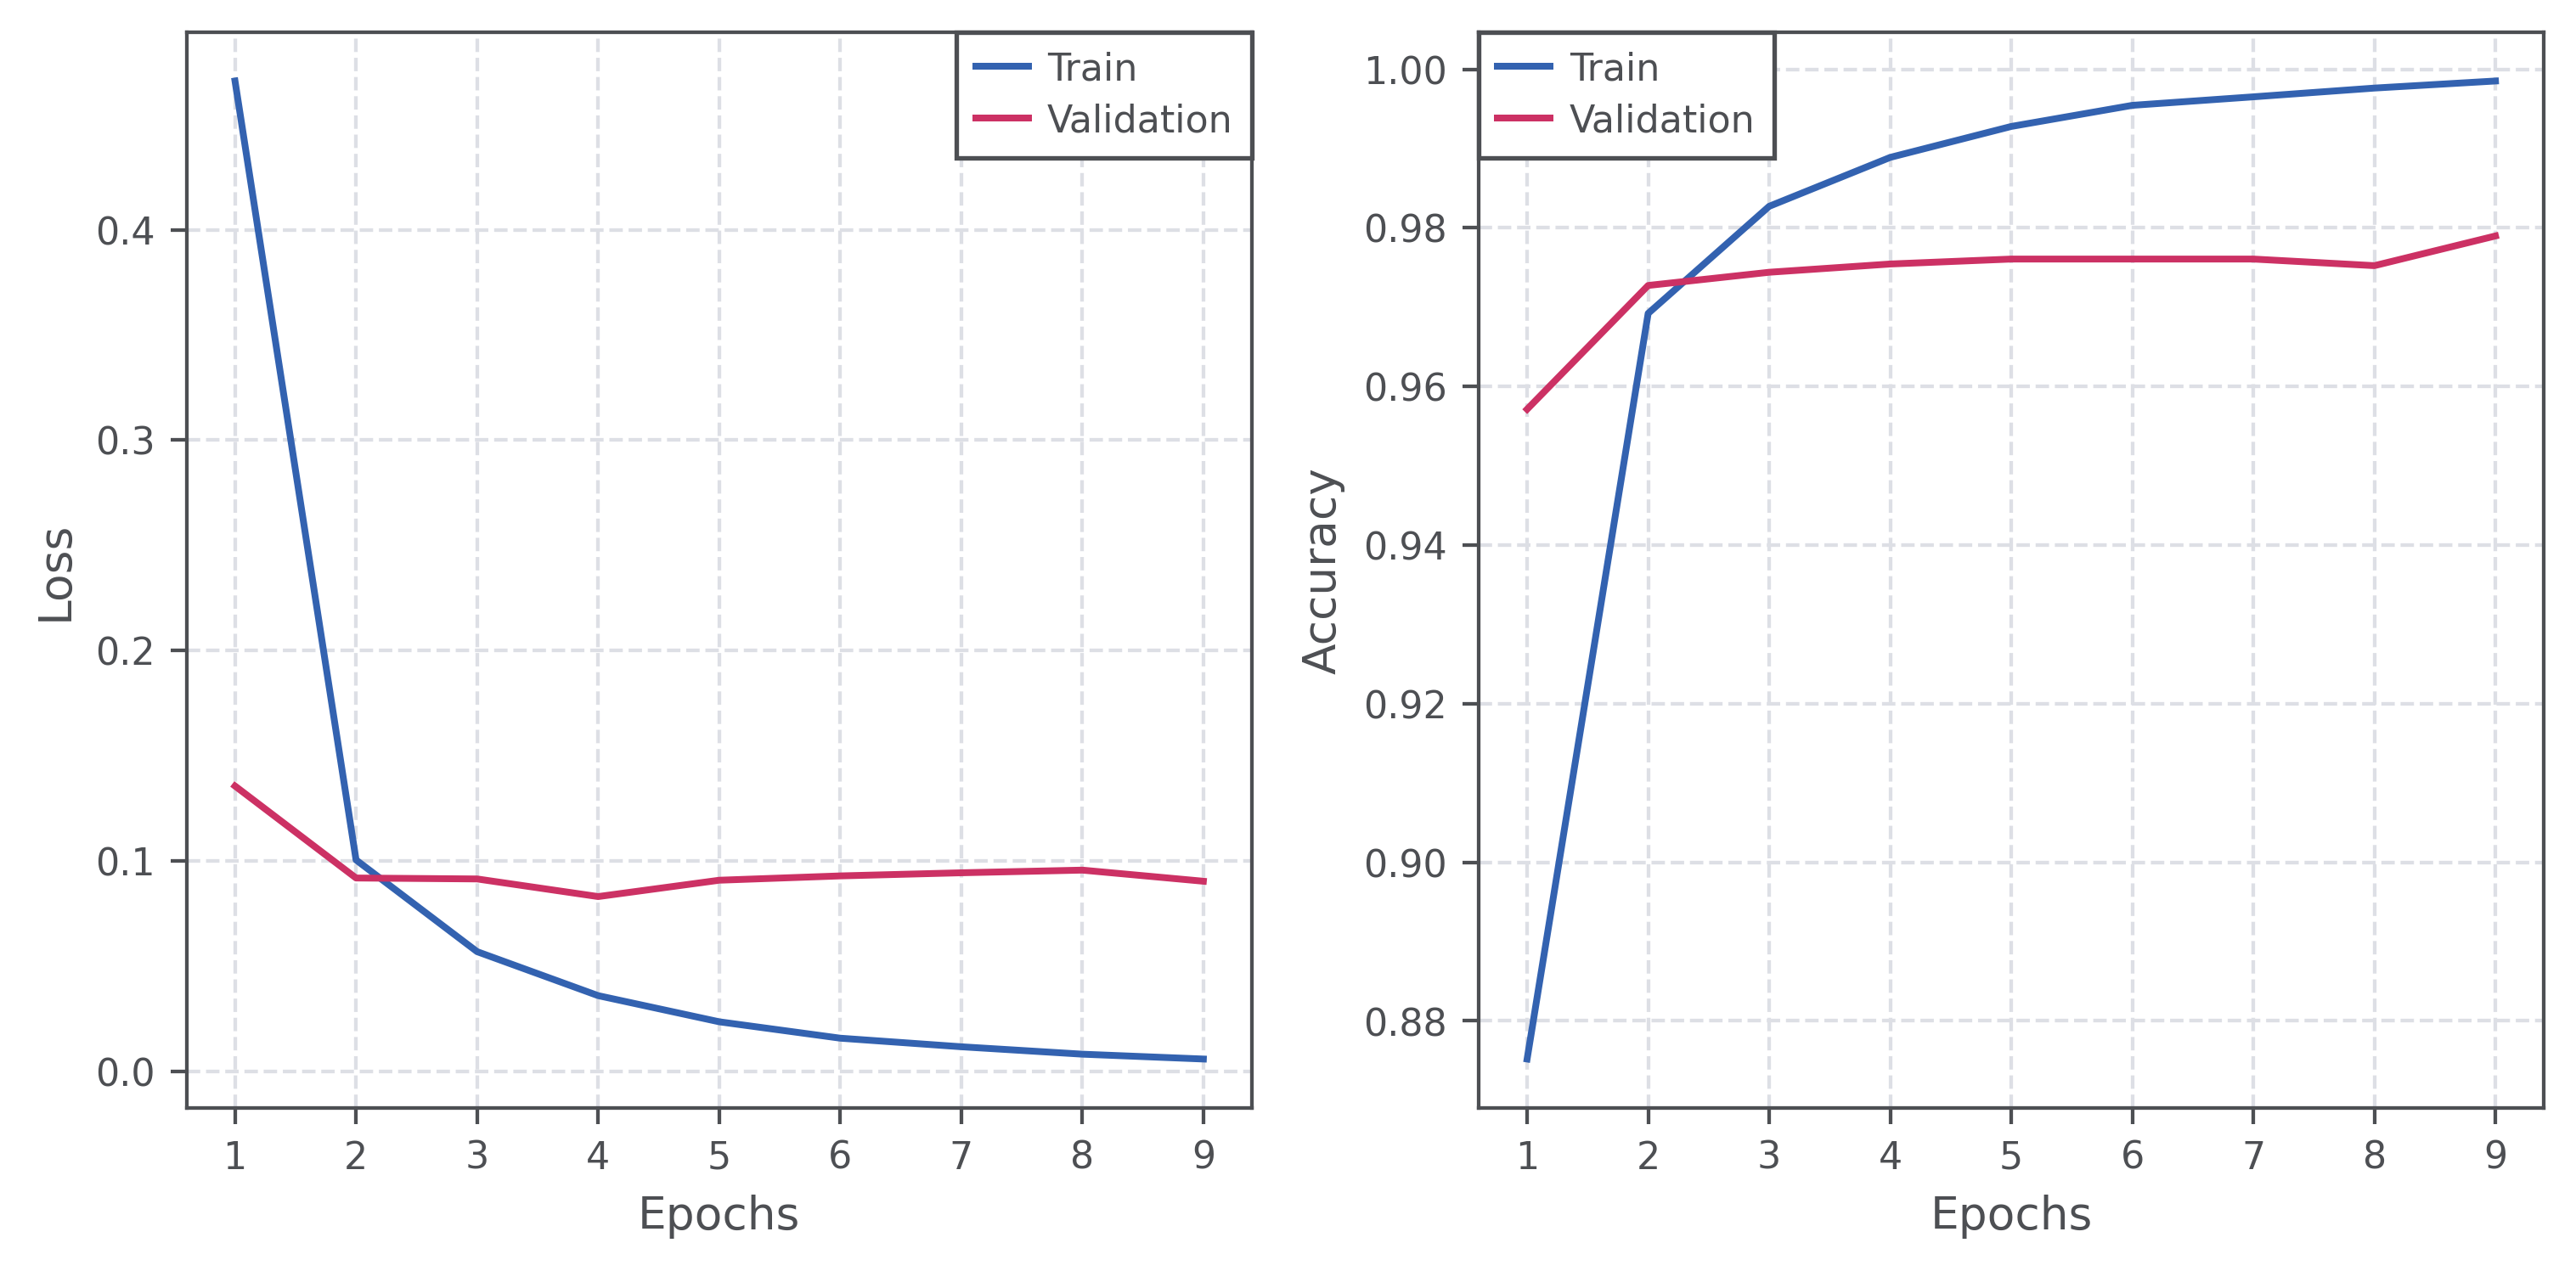

In [8]:
pplt.use_style()
plt.figure(figsize=(8,4))
plt.subplot(121)
plt.plot(np.arange(len(train_loss))+1,train_loss,label='Train')
plt.plot(np.arange(len(validation_loss))+1,validation_loss,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();
plt.subplot(122)
plt.plot(np.arange(len(train_acc))+1,train_acc,label='Train')
plt.plot(np.arange(len(validation_acc))+1,validation_acc,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
pplt.savefig('loss_acc.pdf');

### Evaluate the model on the test dataset

In [9]:
def evaluate(dataloader_val):
    # Pass the model for evaluation
    model.eval()
    # Calculate the total loss
    loss_val_total = 0
    # Store predictions and true values.
    predictions, true_vals = [], []
    for batch in dataloader_val:
        X_batch, y_batch = batch
        X_batch = preprocess(X_batch.to(device))
        y_batch = y_batch.to(device)
        with torch.no_grad():
            # Model prediction for a given batch
            y_pred = model(X_batch.to(torch.float32))
        # Calculating the loss function to use it as a metric
        loss = criterion(y_pred, y_batch)
        # Accumulate the loss function of all data batches.
        loss_val_total += loss.item()
        # Save predictions to use them later
        predictions.extend(y_pred.detach().cpu().numpy())
        # Save the real values ​​to use them later
        true_vals.extend(y_batch.cpu().numpy())

    # Loss of val dataset
    loss_val_avg = loss_val_total / len(dataloader_val)
    # Set of predictions from the dataset
    predictions = np.array(predictions)
    # Id prediction
    predictions = np.argmax(predictions, axis=-1)
    # Set of true values ​​of the dataset
    true_vals = np.array(true_vals)
    return true_vals,predictions#{"loss":loss_val_avg, "accuracy":accuracy_score(true_vals, predictions)}

class_names=dataset_train.classes
y_true,y_pred = evaluate(dataloader_test)
print(classification_report(y_true, y_pred, target_names=class_names))
# print(f"Loss: {metrics['loss']}")
# print(f"Accuracy: {metrics['accuracy']}")

              precision    recall  f1-score   support

    basophil       0.95      0.97      0.96       195
  eosinophil       0.99      0.98      0.99       532
erythroblast       0.98      0.96      0.97       245
          ig       0.94      0.96      0.95       459
  lymphocyte       0.98      0.98      0.98       774
    monocyte       0.95      0.96      0.95       483
  neutrophil       0.99      0.98      0.98      1773
    platelet       1.00      1.00      1.00       353

    accuracy                           0.98      4814
   macro avg       0.97      0.97      0.97      4814
weighted avg       0.98      0.98      0.98      4814



### Compute and plot the confusion matrix

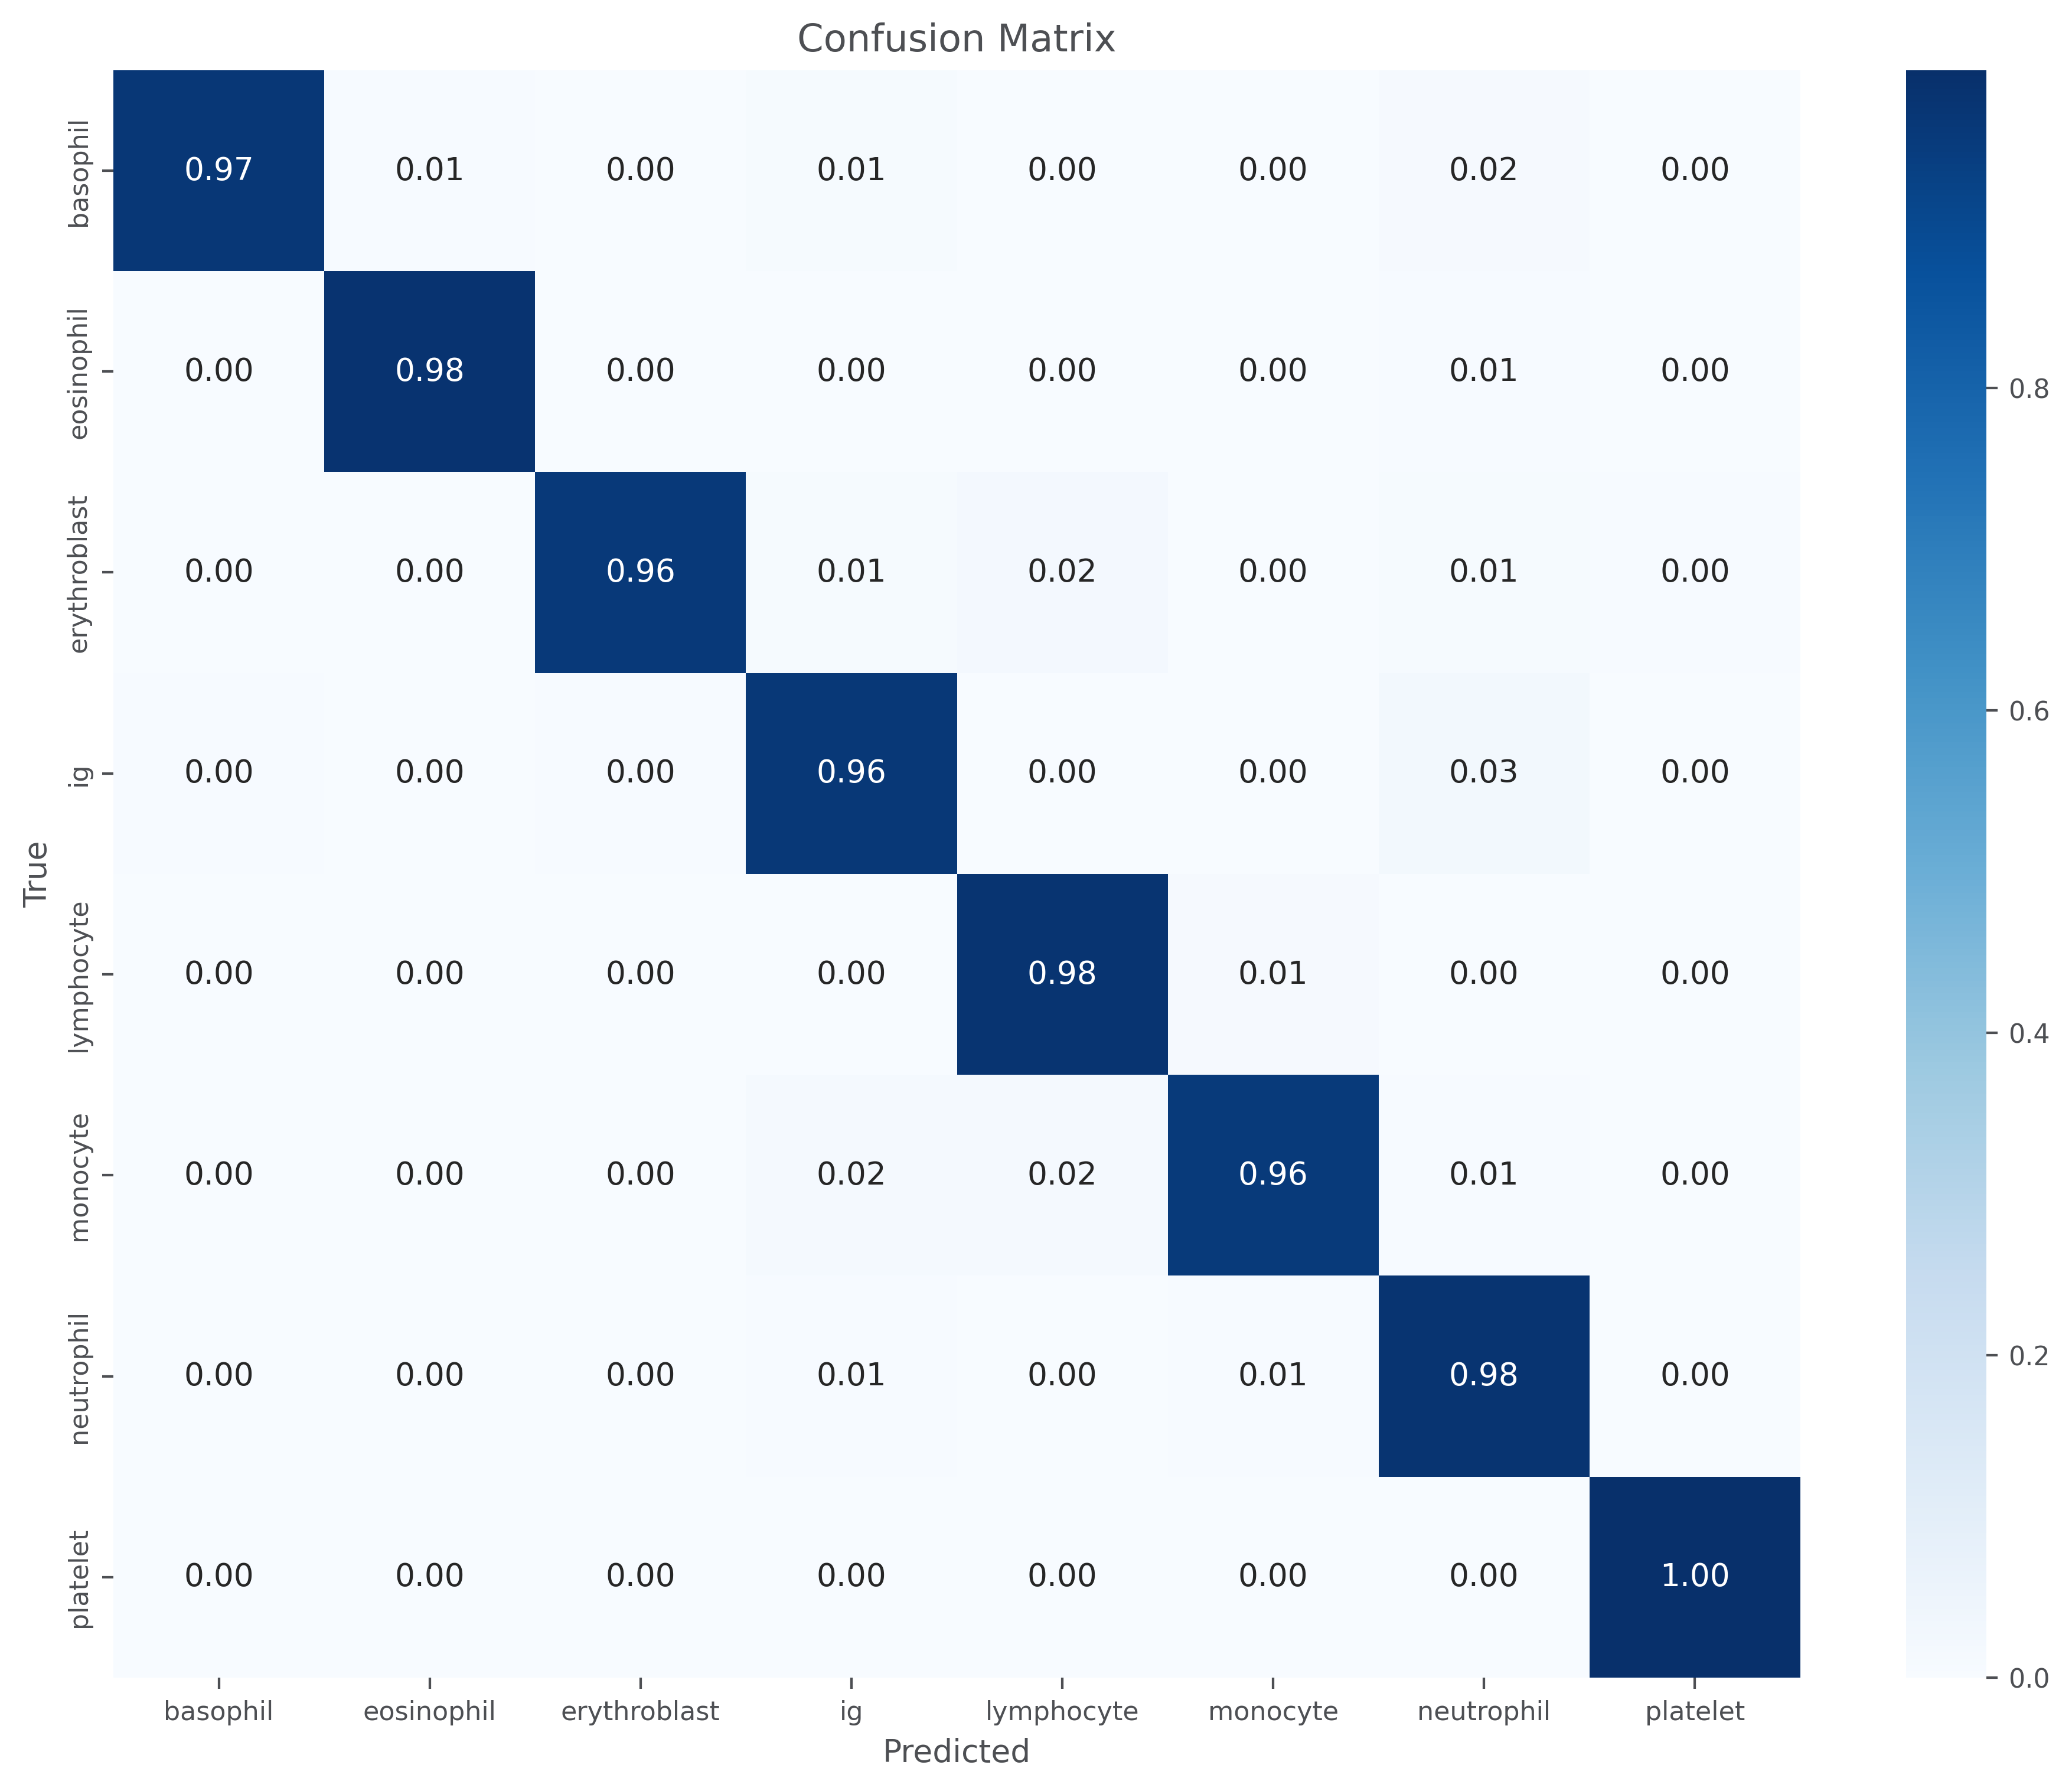

In [10]:
cm = confusion_matrix(y_true, y_pred,normalize='true')
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
pplt.savefig('cm.pdf')
plt.show()

### Save the model and the training history

In [11]:
torch.save(model, 'resnet_model_free_lastlayer.pth')
torch.save(model.state_dict(), 'resnet_model_weights_free_lastlayer.pth')

In [12]:
with open('history_resnet50.txt', 'w') as f:
    for a, b, c, d in zip(train_loss, train_acc, validation_loss, validation_acc):
        f.write(f"{a}\t{b}\t{c}\t{d}\n")